In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random
import pybedtools
import math
from scipy.stats import zscore, fisher_exact, spearmanr, ttest_rel, ttest_ind
import gzip
import ast
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
import yaml
import pandas as pd
from pathlib import Path
import csv
import os

# increases field size limit for large CSV fields
csv.field_size_limit(int(1e6))  

# 
# repo_path = Path('/Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon')

## root path to cloned repo; whereever repo was cloned.
repo_path = Path('./codon_analysis')

os.chdir(repo_path)
print(f"working directory: {os.getcwd()}\n")

# loads config
config_path = Path('configs/read_files/read_files.yaml')
if not config_path.exists():
    # fallback to alternative path if needed
    config_path = Path('config.yaml')
    
print(f"Loading config from: {config_path.absolute()}")

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# extracts loading config and input file paths
loading_config = config['loading_config']
input_files = config['input_files']
print(f"config loaded successfully!\n")

working directory: /Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon

Loading config from: /Users/jacobfine/Library/CloudStorage/OneDrive-Personal/U of T 2022-2023/Blencowe/Jan_2024_Blencowe/NOV_2024_reanalysis/sequence_analysis_may_2026/compare_backgrounds_codon/configs/read_files/read_files.yaml
config loaded successfully!



In [3]:
# master table for kmers
kmers_gene_master = pd.read_csv(
    input_files['kmers']['gene_master']['path'],
    sep=loading_config['csv']['sep'],
    encoding=loading_config['csv']['encoding'],
    index_col=loading_config['csv']['index_col'],
    engine='python',
    on_bad_lines='skip'
)


In [4]:
# htt expression tables; for two htt studies
print("loading DESeq2 HTT results")

## the ipsc consitrum study

deseq_ipsc_results = pd.read_csv(
    input_files['deseq_htt']['ipsc_consortium']['deseq_results']['path'],
    sep=loading_config['csv']['sep'],
    encoding=loading_config['csv']['encoding'],
    index_col=loading_config['csv']['index_col'],
    engine='python'
)
print(f"iPSC consortium DESeq2 results: {deseq_ipsc_results.shape}")


## the plos one study 
deseq_ipsc_normalized_counts = pd.read_csv(
    input_files['deseq_htt']['ipsc_consortium']['normalized_counts']['path'],
    sep=loading_config['csv']['sep'],
    encoding=loading_config['csv']['encoding'],
    index_col=loading_config['csv']['index_col'],
    engine='python'
)
print(f"iPSC consortium normalized counts: {deseq_ipsc_normalized_counts.shape}")

deseq_plos_one_htt_xls = pd.ExcelFile(input_files['deseq_htt']['plos_one_study']['path'])
print(f"  Available sheets in PLOS one HTT file: {deseq_plos_one_htt_xls.sheet_names}")

deseq_plos_one_htt = pd.read_excel(
    input_files['deseq_htt']['plos_one_study']['path'],
    sheet_name=None  
)

print(f"  PLOS one HTT sheets loaded:")
for sheet_name, df in deseq_plos_one_htt.items():
    print(f"    {sheet_name}: {df.shape}")
print(f"PLOS one HTT study data: {len(deseq_plos_one_htt)} sheets loaded")

# mRNA stability data
print("Loading mRNA stability data")

rna_stability_pcbi = pd.read_csv(
    input_files['rna_stability']['mrna_stability']['path'],
    sep=loading_config['csv']['sep'],
    encoding='latin-1',  
    index_col=loading_config['csv']['index_col'],
    engine='python'
)
print(f"mRNA stability (PCBI): {rna_stability_pcbi.shape}")

# ribosome profiling data (from Cothani et al.)
print("Loading ribosome profiling TPM data")

# Load all sheets from Cothani data
riboprof_sheets = pd.read_excel(
    input_files['riboprof']['rna_ribo_tpms']['path'],
    sheet_name=None 
)

print(f" sheets in ribosome profiling file:")
for sheet_name, df in riboprof_sheets.items():
    print(f"    {sheet_name}: {df.shape}")

# riboprof_rna_ribo_tpms contains all sheets as a dict
riboprof_rna_ribo_tpms = riboprof_sheets


print(f"Cothani data; {len(riboprof_sheets)} sheets loaded")

# gene ontology information
print("Loading Gene Ontology functional associations")

go_functional_associations = pd.read_csv(
    input_files['go_annotation']['functional_associations']['path'],
    sep=loading_config['csv']['sep'],
    encoding=loading_config['csv']['encoding'],
    index_col=loading_config['csv']['index_col'],
    engine='python'
)
print(f"GO functional associations: {go_functional_associations.shape}")

# informaoitn form processing sequneces
print("loading sequence processing data")

seq_process_longest_orfs_expanded = pd.read_csv(
    input_files['seq_process']['longest_orfs_expanded']['path'],
    sep=loading_config['csv']['sep'],
    encoding=loading_config['csv']['encoding'],
    index_col=loading_config['csv']['index_col'],
    engine='python'
)
print(f"Longest CDSs expanded: {seq_process_longest_orfs_expanded.shape}")

seq_process_coordinates = pd.read_csv(
    input_files['seq_process']['coordinates']['path'],
    sep=loading_config['csv']['sep'],
    encoding=loading_config['csv']['encoding'],
    index_col=loading_config['csv']['index_col'],
    engine='python'
)



loading DESeq2 HTT results
iPSC consortium DESeq2 results: (17713, 7)
iPSC consortium normalized counts: (17713, 7)
  Available sheets in PLOS one HTT file: ['A.all_genes_DE_stats', 'B.HD_CAGadjOnset_assoc', 'C.HD_CAG.Size_assoc', 'D.HD_Cortical_assoc', 'E.HD_striatal_assoc', 'F.HOX_genes']
  PLOS one HTT sheets loaded:
    A.all_genes_DE_stats: (28087, 11)
    B.HD_CAGadjOnset_assoc: (28087, 9)
    C.HD_CAG.Size_assoc: (28087, 9)
    D.HD_Cortical_assoc: (28087, 9)
    E.HD_striatal_assoc: (28087, 9)
    F.HOX_genes: (30, 10)
PLOS one HTT study data: 6 sheets loaded
Loading mRNA stability data
mRNA stability (PCBI): (9852, 20)
Loading ribosome profiling TPM data
 sheets in ribosome profiling file:
    RNAseq_TPM: (85160, 12)
    RNAseqL29_TPM: (28190, 12)
    Riboseq_TPM: (28190, 12)
Cothani data; 3 sheets loaded
Loading Gene Ontology functional associations
GO functional associations: (20274, 10)
loading sequence processing data
Longest CDSs expanded: (199904, 10)


In [5]:
import pandas as pd

seq_process_coordinates = pd.read_csv(
    'input_files/seq_process/hg_coords_names.csv',
    engine='python')
print(seq_process_coordinates.head())
print(f"\nshape: {seq_process_coordinates.shape}")


lookup_common_name = dict(zip(seq_process_coordinates['gene'],seq_process_coordinates['common_name']))


## matched gc-length genes
genes_GC_len_sample = pd.read_csv(config['outputs']['files']['output_kmers']['path']+'genes_GC_len_sample.csv')
gc_len_genes = list(set(genes_GC_len_sample['name']))
len(gc_len_genes)



gc_len_genes_common = [lookup_common_name[g] for g in gc_len_genes]

   Unnamed: 0             gene chrom  start    end strand  common_name
0           0  ENSG00000223972  chr1  12010  13670      +      DDX11L1
1           1  ENSG00000227232  chr1  14404  29570      -       WASH7P
2           2  ENSG00000278267  chr1  17369  17436      -    MIR6859-1
3           3  ENSG00000243485  chr1  29554  31109      +  MIR1302-2HG
4           4  ENSG00000284332  chr1  30366  30503      +    MIR1302-2

shape: (62702, 7)


In [6]:
import os
from pathlib import Path

# Load bed files from output directory
bed_dir = Path('outputs/files/output_kmers/')

bed_dict = {}

# Read the bed files in the directory
for filename in os.listdir(bed_dir):
    if filename.endswith(".bed"):
        filepath = os.path.join(bed_dir, filename)
        kmer_set_name = filename.replace(".bed", "")
        
        
        # make bed files into df
        df = pd.read_csv(filepath, sep='\t', header=None,
                         names=["chrom", "start", "end", "name", "score", "strand"])
        df["name"] = df["name"] + "---" + kmer_set_name  # indicates where it came from
        bed_dict[kmer_set_name] = df
        print(f"Loaded {kmer_set_name}: {df.shape}")

#make single df from all the kmers
combined_df_kmers = pd.concat(bed_dict.values(), ignore_index=True)

# makes identifiers for each kmer based on coords and gene name
combined_df_kmers['genomic_id'] = (
    combined_df_kmers['chrom'].astype(str) + ":" + 
    combined_df_kmers['start'].astype(str) + "-" + 
    combined_df_kmers['end'].astype(str) + "---" + 
    combined_df_kmers['name'].astype(str)
)

print(f"\ncombined dataframe: {combined_df_kmers.shape}")
print(f"k-mer sets loaded: {list(bed_dict.keys())}")


Loaded within_genes: (571, 6)
Loaded between_genes: (1508, 6)
Loaded rare_patches: (482, 6)

combined dataframe: (2561, 7)
k-mer sets loaded: ['within_genes', 'between_genes', 'rare_patches']


In [7]:
def GC(sequence):
    if type(sequence)==str:
        if len(sequence) > 0 and ('Seq' not in sequence):
            # Count the number of G and C nucleotides in the sequence
            gc_count = sequence.count('G') + sequence.count('C')
            # Calculate the GC content as a fraction of the total length of the sequence
            gc_fraction = round(gc_count / len(sequence), 3)
            return gc_fraction
        else:
            return np.nan
    else:
        return np.nan

In [8]:
import yaml
from pathlib import Path
import pandas as pd

# Load config
config_path = Path('configs/read_files/read_files.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

loading_cfg = config['loading_config']

# load longest ORF information
df_longest_orf = pd.read_csv(
    config['input_files']['seq_process']['longest_orfs']['path'],
    **loading_cfg['csv']
)
all_coding_genes = list(set(df_longest_orf['name']))

print(f"Loaded longest ORFs: {df_longest_orf.shape}")
print(f"Total coding genes: {len(all_coding_genes)}")

# Load gene coordinates
df_gene_coords = pd.read_csv(
    config['input_files']['seq_process']['coordinates']['path'],
    **loading_cfg['csv']
)

print(f"Loaded gene coordinates: {df_gene_coords.shape}")
## gets the host gene name from the kmer name
def extract_host_gene(name):
    if '---rare_patches' in name:
        return name.split('_(')[0]  
    else:
        return name.split('__')[0]

def extract_kmer_set(name):
    if '---rare_patches' in name:
        return 'rare_patches'
    else:
        return name.split('---')[-1]

combined_df_kmers['host_gene'] = combined_df_kmers['name'].apply(extract_host_gene)
combined_df_kmers['kmer_set'] = combined_df_kmers['name'].apply(extract_kmer_set)

print(f"\nk-mer sets found: {combined_df_kmers['kmer_set'].unique()}")
print(f"Total k-mers: {len(combined_df_kmers)}")

all_kmer_info = combined_df_kmers[['name', 'host_gene', 'kmer_set', 'chrom', 'start', 'end', 'strand']].copy()

print(f"\nall k-mer info: {all_kmer_info.shape}")

output_dir = config['outputs']['figures']['categorical_plots']['path']
output_dir

Loaded longest ORFs: (20202, 6)
Total coding genes: 20202
Loaded gene coordinates: (62702, 7)

k-mer sets found: ['within_genes' 'between_genes' 'rare_patches']
Total k-mers: 2561

all k-mer info: (2561, 7)


'outputs/figures/categorical_plots/'

In [9]:
all_kmer_info['host_gene_common']=all_kmer_info['host_gene'].map(lookup_common_name)



In [10]:
rare_patches = all_kmer_info[all_kmer_info['kmer_set'] =='rare_patches']

rcpgs_list = list(set(rare_patches['host_gene'].dropna()))


rcpgs_list_common= list(set(rare_patches['host_gene_common'].dropna()))


In [ ]:
seq_process_longest_orfs = seq_process_longest_orfs_expanded.drop_duplicates('gene')

seq_process_longest_orfs['gene']=seq_process_longest_orfs['gene'].str.split('.').str[0]
seq_process_longest_orfs['GC'] = seq_process_longest_orfs['assembled_ORF'].apply(GC)

seq_process_longest_orfs['length'] = seq_process_longest_orfs['assembled_ORF'].str.len()

seq_process_longest_orfs['is_rare']= seq_process_longest_orfs['gene'].isin(rcpgs_list)

seq_process_longest_orfs['is_gc_length']=seq_process_longest_orfs['gene'].isin(gc_len_genes_common)

In [12]:
background_genes = gc_len_genes.copy() 

# Load all sheets from Cothani data
riboprof_sheets = pd.read_excel(
    input_files['riboprof']['rna_ribo_tpms']['path'],
    sheet_name=None  # Load all sheets
)

riboprof_rna_ribo_tpms = riboprof_sheets
sheets_dict = riboprof_sheets.copy() 

In [13]:
## for comparing rna-seq to ribo-seq

df_merge = pd.merge(sheets_dict['Riboseq_TPM'],sheets_dict['RNAseq_TPM'],on='Unnamed: 0',how='inner',suffixes=['_ribo','_rna'])
df_merge['is_gene']  =  df_merge['Unnamed: 0'].isin(all_coding_genes)
df_merge = df_merge[df_merge['is_gene']]
df_merge['common_name'] = df_merge['Unnamed: 0'].map(lookup_common_name)
df_merge['ensg_name'] =df_merge['Unnamed: 0'].copy()
df_merge['is_rare'] = df_merge['ensg_name'].isin(rcpgs_list)
df_merge['is_background'] = df_merge['ensg_name'].isin(gc_len_genes)
rna_cols = [col for col in df_merge.columns if '_rna' in col]
ribo_cols = [col for col in df_merge.columns if '_ribo' in col]


In [14]:
%load_ext rpy2.ipython

In [15]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import re

# extract tissues from column names from df
ribo_cols = [col for col in df_merge.columns if '_ribo' in col]
rna_cols = [col for col in df_merge.columns if '_rna' in col]

# get the tissue names (remove _ribo and _rna suffixes)
tissues = [col.replace('_ribo', '') for col in ribo_cols]


# make the expression data into long form 
rows = []

for idx, row in df_merge.iterrows():
    for tissue in tissues:
        ribo_col = f"{tissue}_ribo"
        rna_col = f"{tissue}_rna"
        
        rows.append({
            'gene': row['ensg_name'],
            'common_name': row['common_name'],
            'tissue': tissue,
            'score_ribo': row[ribo_col],
            'score_rna': row[rna_col],
            'is_rare': row['is_rare'],
            'is_background': row['is_background'],
            'is_gene': row['is_gene'],
        })

df_long = pd.DataFrame(rows)

# looks up the orf length 
lookup_orf_len = dict(zip(df_longest_orf['name'],df_longest_orf['assembled_ORF'].str.len()))

df_long['orf_length']=df_long['gene'].map(lookup_orf_len)


# Log transforms
df_long['log_ribo'] = np.log1p(df_long['score_ribo'])
df_long['log_rna'] = np.log1p(df_long['score_rna'])
df_long['log_orf_length'] = np.log1p(df_long['orf_length'])


# default make them all
df_long['group'] = 'all'

## then update the specific groups of the genes
df_long.loc[df_long['is_rare'], 'group'] = 'rare'
df_long.loc[df_long['is_background'], 'group'] = 'background'



In [16]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, mannwhitneyu

# keep only rows where score_rna and score_ribo > 1
df_long = df_long[(df_long['score_rna'] > 1) & (df_long['score_ribo'] > 1)].copy()


# regress  log ribo on log rna (OLS)
df_long['log_ribo'] = (df_long['score_ribo'])
df_long['log_rna'] = (df_long['score_rna'])

print("fitting OLS of log(ribo) on log(rna)")
ols_model = smf.ols("log_ribo ~ log_rna", data=df_long).fit()

# extract residuals from model
df_long['ribo_resid'] = ols_model.resid

# compares residuals between groups
def group_stats(df_long, score_col, test="ttest_ind"):

    comparisons = [("all", "background"), ("background", "rare"), ("all", "rare")]
    results = []
    
    df_filtered = df_long[df_long[score_col].notna()].copy()
    
    for g1, g2 in comparisons:
        x = df_filtered.loc[df_filtered["group"] == g1, score_col].dropna()
        y = df_filtered.loc[df_filtered["group"] == g2, score_col].dropna()
        
        if test == "ttest_ind":
            stat, pval = ttest_ind(x, y, equal_var=False)
        else:
            stat, pval = mannwhitneyu(x, y, alternative="two-sided")
        
        results.append({
            "group1": g1,
            "group2": g2,
            "n1": len(x),
            "n2": len(y),
            "mean1": x.mean(),
            "mean2": y.mean(),
            "statistic": stat,
            "p_value": pval
        })
    
    return pd.DataFrame(results)



fitting OLS of log(ribo) on log(rna)


In [17]:
# average each gene across all tissues, for running tests
df_long_by_gene = df_long.groupby('gene').agg({
    'ribo_resid': 'mean',
    'log_ribo': 'mean',
    'log_rna': 'mean',
    'score_ribo': 'mean',
    'score_rna': 'mean',
    'is_rare': 'first',
    'is_background': 'first',
    'group': 'first'
}).reset_index()

# run the stats on OLS residuals
stats_resid = group_stats(df_long_by_gene, score_col='ribo_resid', test="ttest_ind")
stats_resid

,group1,group2,n1,n2,mean1,mean2,statistic,p_value
0,all,background,14843,571,5.458774,-30.803432,4.342753,0.000015
1,background,rare,571,346,-30.803432,-85.602438,2.277685,0.023261
2,all,rare,14843,346,5.458774,-85.602438,3.876413,0.000125


## HTT analysis (iPSC consortium)

In [18]:
import pandas as pd
df_deseq_path = config['input_files']['deseq_htt']['ipsc_consortium']['deseq_results']['path']
output_dir = config['outputs']['figures']['categorical_plots']['path']

## processed deseq file
df_deseq = pd.read_csv(df_deseq_path)


In [19]:
df_longest_orf['common_name']=df_longest_orf['name'].map(lookup_common_name)
all_coding_genes_common_name = list(set(df_longest_orf['common_name']))

In [20]:
df_deseq['is_coding']=df_deseq['Unnamed: 0'].isin(all_coding_genes_common_name)
df_deseq= df_deseq[df_deseq['is_coding']]

In [21]:
df_deseq['name'] =df_deseq['Unnamed: 0']
df_deseq['is_rare'] =  df_deseq['name'].isin(rcpgs_list_common)
df_deseq['is_background']= df_deseq['name'].isin(gc_len_genes_common)
df_deseq['is_de'] = (df_deseq['padj'] < 0.05) ## cutoff for whether gene is de

df_deseq=df_deseq[df_deseq['padj'].notna()]

df_deseq = df_deseq[df_deseq['baseMean']>1]
df_deseq

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,is_coding,name,is_rare,is_background,is_de
1,SAMD11,1269.108049,1.325171,0.445389,2.975316,2.926871e-03,0.022987,True,SAMD11,False,False,True
2,NOC2L,2462.365473,0.294087,0.204842,1.435676,1.510947e-01,0.332822,True,NOC2L,False,False,False
3,KLHL17,997.216601,-0.197341,0.278162,-0.709445,4.780482e-01,0.677944,True,KLHL17,False,False,False
4,PLEKHN1,17.129072,-1.047784,0.704867,-1.486498,1.371473e-01,0.312402,True,PLEKHN1,False,False,False
5,PERM1,14.053913,0.476622,0.989476,0.481692,6.300250e-01,0.788084,True,PERM1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
17670,CLIC2,390.077904,2.713604,0.539810,5.026962,4.983100e-07,0.000036,True,CLIC2,False,False,True
17672,TMLHE,365.463502,-0.166241,0.378077,-0.439702,6.601527e-01,0.809362,True,TMLHE,False,False,False
17673,SPRY3,291.610555,-0.696225,0.558499,-1.246601,2.125439e-01,0.414543,True,SPRY3,False,False,False
17674,VAMP7,1283.182304,0.643792,0.208821,3.082986,2.049351e-03,0.017495,True,VAMP7,False,False,True


In [22]:
from scipy.stats import fisher_exact, ttest_ind
import pandas as pd

# perform FET for is_rare vs is_de
contingency_rare = pd.crosstab(df_deseq['is_rare'], df_deseq['is_de'])
print("s_rare vs is_de")
print(contingency_rare)

odds_rare, pval_rare = fisher_exact(contingency_rare)
print(f"\nFisher's exact test (is_rare vs is_de):")
print(f"  Odds ratio: {odds_rare:.4f}")
print(f"  p-value: {pval_rare:.4e}\n")

# perform FET for is_background vs is_de
contingency_bg = pd.crosstab(df_deseq['is_background'], df_deseq['is_de'])
print("is_background vs is_de")
print(contingency_bg)

odds_bg, pval_bg = fisher_exact(contingency_bg)
print(f"\nFET (is_background vs is_de):")
print(f"  Odds ratio: {odds_bg:.4f}")
print(f"  p-value: {pval_bg:.4e}\n")

s_rare vs is_de
is_de    False  True 
is_rare              
False    11752   2509
True       253     73

Fisher's exact test (is_rare vs is_de):
  Odds ratio: 1.3515
  p-value: 2.7621e-02

is_background vs is_de
is_de          False  True 
is_background              
False          11534   2467
True             471    115

FET (is_background vs is_de):
  Odds ratio: 1.1415
  p-value: 2.2406e-01



In [23]:
%R -i df_deseq -i output_dir


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: package ‘ggplot2’ was built under R version 4.5.3 
2: package ‘dplyr’ was built under R version 4.5.3 


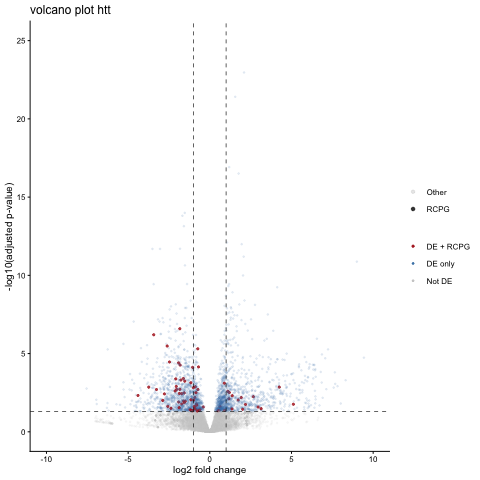

In [24]:
%%R
## to visualize differential expression upon repeat expansion

library(ggplot2)
library(dplyr)

df <- df_deseq %>% 
  filter(!is.na(padj)) %>%
  mutate(
    category = case_when(
      is_de & is_rare ~ "DE + RCPG",
      is_de & !is_rare ~ "DE only",
      TRUE ~ "Not DE"
    ),
    is_rcpg = ifelse(is_rare, "RCPG", "Other")  # new flag
  )

log2fc_thresh <- 1
padj_thresh <- 0.05

p <- ggplot(df, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(aes(color = category, size = category, alpha = is_rcpg)) +
  geom_vline(xintercept = c(-log2fc_thresh, log2fc_thresh),
             linetype = "dashed", color = "black", linewidth = 0.3) +
  geom_hline(yintercept = -log10(padj_thresh),
             linetype = "dashed", color = "black", linewidth = 0.3) +
  scale_color_manual(
    values = c("Not DE" = "gray80",
               "DE only" = "steelblue",
               "DE + RCPG" = "firebrick")
  ) +
  scale_size_manual(
    values = c("Not DE" = 0.5,
               "DE only" = 0.5,
               "DE + RCPG" = 0.75)
  ) +
  scale_alpha_manual(
    values = c("Other" = 0.1, "RCPG" = 0.8)
  ) +
  xlim(-10, 10) +
  ylim(0, 25) +
  theme_classic(base_size = 10) +
  labs(
    x = "log2 fold change",
    y = "-log10(adjusted p-value)",
    title = "volcano plot htt",
    color = NULL,
    size = NULL,
    alpha = NULL
  )

# save
ggsave(
  filename = paste0(output_dir, "HTT_de_volcano_DE_RCPG_big_v2.pdf"),
  plot = p,
  width = 5,
  height = 5
)

print(p)

In [25]:
## the plos one HTT dataset
deseq_plos_one_htt_xls = pd.ExcelFile(input_files['deseq_htt']['plos_one_study']['path'])
print(f"  Available sheets in PLOS ONE HTT file: {deseq_plos_one_htt_xls.sheet_names}")

deseq_plos_one_htt = pd.read_excel(
    input_files['deseq_htt']['plos_one_study']['path'],
    sheet_name=None 
)


  Available sheets in PLOS ONE HTT file: ['A.all_genes_DE_stats', 'B.HD_CAGadjOnset_assoc', 'C.HD_CAG.Size_assoc', 'D.HD_Cortical_assoc', 'E.HD_striatal_assoc', 'F.HOX_genes']


In [26]:
HTT_rna_seq = deseq_plos_one_htt['A.all_genes_DE_stats'] ## selects appropriate table

In [27]:
HTT_rna_seq['ensg_name']=HTT_rna_seq['ENSG'].str.split('.').str[0]
HTT_rna_seq = HTT_rna_seq[HTT_rna_seq['ensg_name'].isin(all_coding_genes)]
HTT_rna_seq

df_labadorf = HTT_rna_seq.copy()


In [28]:
# for consistnetcy
background_gc_ensg = background_genes
len(background_genes)

716

In [29]:
df_master = kmers_gene_master.copy()

In [30]:
from scipy.stats import fisher_exact
import pandas as pd
import numpy as np
from scipy import stats

# Strip version numbers from ENSG
df_labadorf['ensg_stripped'] = df_labadorf['ENSG'].str.split('.').str[0]

# Create gene sets
rcegs_set = set([ensg.split('.')[0] if '.' in str(ensg) else ensg for ensg in df_master['ensg_name_x'].dropna()])
background_gc_ensg_stripped = set([ensg.split('.')[0] if '.' in str(ensg) else ensg for ensg in background_gc_ensg])
df_labadorf['is_DE'] = (df_labadorf['padj'] < 0.05) ## de cutoff

df_labadorf['is_RCPG'] = df_labadorf['ensg_stripped'].isin(rcegs_set)
df_labadorf['is_background'] = df_labadorf['ensg_stripped'].isin(background_gc_ensg_stripped)


results_fisher = []

# Test each gene set
for gene_set_name, gene_set_col in [('RCPGs', 'is_RCPG'),
                                     ('GC_background', 'is_background')]:

    cont_table = pd.crosstab(df_labadorf[gene_set_col], df_labadorf['is_DE'])
    cont_table = cont_table.reindex(index=[False, True], columns=[False, True], fill_value=0)

    table = [
        [cont_table.loc[False, False], cont_table.loc[False, True]],
        [cont_table.loc[True, False], cont_table.loc[True, True]]
    ]

    odds, pval = fisher_exact(table, alternative='greater')

    n_genes = df_labadorf[gene_set_col].sum()
    n_overlap = cont_table.loc[True, True]
    de_prop = n_overlap / n_genes if n_genes > 0 else 0

    results_fisher.append({
        'gene_set': gene_set_name,
        'n_genes': n_genes,
        'overlap_DE': n_overlap,
        'proportion_DE': round(de_prop, 3),
        'odds_ratio': round(odds, 2),
        'pvalue': pval,
    })

    # Post-hoc: mean log2FC among DE genes only
    de_in_set = df_labadorf[gene_set_col] & df_labadorf['is_DE']
    de_rest = (~df_labadorf[gene_set_col]) & df_labadorf['is_DE']

    gene_set_values = df_labadorf.loc[de_in_set, 'log2FoldChange'].dropna().values
    rest_values = df_labadorf.loc[de_rest, 'log2FoldChange'].dropna().values

    gene_set_lfc = gene_set_values.mean() if len(gene_set_values) else np.nan
    rest_lfc = rest_values.mean() if len(rest_values) else np.nan

    if len(gene_set_values) >= 2 and len(rest_values) >= 2:
        t_stat, t_pval = stats.ttest_ind(gene_set_values, rest_values, equal_var=False)
    else:
        t_stat, t_pval = np.nan, np.nan



df_fisher = pd.DataFrame(results_fisher)

print(df_fisher.to_string(index=False))



     gene_set  n_genes  overlap_DE  proportion_DE  odds_ratio   pvalue
        RCPGs      369         109          0.295        1.32 0.010212
GC_background      650         169          0.260        1.10 0.147955


## HALF-LIFE experiments

In [31]:
## load the half life dataset
rna_stability_pcbi = pd.read_csv(
    input_files['rna_stability']['mrna_stability']['path'],
    sep=loading_config['csv']['sep'],
    encoding='latin-1',  # Use latin-1 instead of utf-8
    index_col=loading_config['csv']['index_col'],
    engine='python'
)
print(f"mRNA stability (PCBI): {rna_stability_pcbi.shape}")

df_pcbi = rna_stability_pcbi.copy()

mRNA stability (PCBI): (9852, 20)


In [32]:
import numpy as np
# compute the log2 transformation once
df_pcbi['NucCyt Half-Life Average [min]'] =(df_pcbi['Nuclear Half-Life Average [min]'] + df_pcbi['Cytosolic Half-Life Average [min]'])/2
log2_nuc_hl = np.log(df_pcbi['Nuclear Half-Life Average [min]'] + 1)
log2_cyt_hl = np.log(df_pcbi['Cytosolic Half-Life Average [min]'] + 1)
log2_nuccyt_hl = np.log(df_pcbi['NucCyt Half-Life Average [min]'] + 1)
# Z-normalize the log2-transformed data
df_pcbi['Z-nuc_hl'] = (log2_nuc_hl - log2_nuc_hl.mean()) / log2_nuc_hl.std()
df_pcbi['Z-cyt_hl'] = (log2_cyt_hl - log2_cyt_hl.mean()) / log2_cyt_hl.std()

df_pcbi['Z-nuccyt-hl'] = (log2_nuccyt_hl-log2_nuccyt_hl.mean())/log2_nuccyt_hl.std()

In [33]:
df_pcbi['LOG2 NucCyt Half-Life Average [min]'] = log2_nuccyt_hl

In [34]:
## define rcpgs and background
df_pcbi['is_rare']  = df_pcbi["Gene Name"].isin(rcpgs_list_common)
df_pcbi['is_background']  = df_pcbi["Gene Name"].isin(gc_len_genes_common)
# lookup halflife from gene name
lookup_halflife = dict(zip(df_pcbi['Gene Name'], df_pcbi['LOG2 NucCyt Half-Life Average [min]']))
df_long['hl_pcbi']=df_long['common_name'].map(lookup_halflife)

In [35]:
df_long_no_dup = df_long.groupby('common_name', as_index=False)['ribo_resid'].mean()
lookup_ribo = dict(zip(df_long_no_dup['common_name'],df_long_no_dup['ribo_resid']))

In [36]:
outdir = config['outputs']['figures']['categorical_plots']['path']


 group stats 
# A tibble: 3 × 5
  group          n  mean    sd    sem
  <fct>      <int> <dbl> <dbl>  <dbl>
1 All         9285  5.37 1.12  0.0116
2 Background   372  5.20 1.30  0.0672
3 Rare         195  4.82 0.921 0.0660


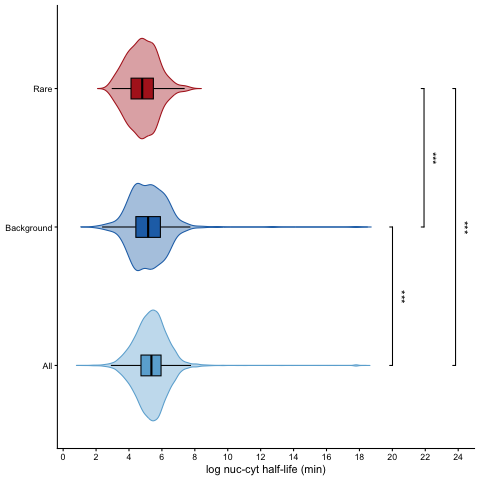

In [37]:
%%R -i outdir -i df_pcbi

## plots the half life data as a function of gene set
# 
df_pcbi$group <- "All"
df_pcbi$group[df_pcbi$is_background] <- "Background"
df_pcbi$group[df_pcbi$is_rare] <- "Rare"

df_vln <- df_pcbi


cat("\n group stats \n")
summary_stats <- df_vln %>%
  group_by(group) %>%
  summarise(
    n = n(),
    mean = mean(`LOG2 NucCyt Half-Life Average [min]`, na.rm = TRUE),
    sd = sd(`LOG2 NucCyt Half-Life Average [min]`, na.rm = TRUE),
    sem = sd / sqrt(n),
    .groups = 'drop'
  ) %>%
  mutate(group = factor(group, levels = c("All", "Background", "Rare"))) %>%
  arrange(group)

print(summary_stats)

plot_horizontal_raincloud <- function(df, y_col, group_col,
                                      group_levels = c("All", "Background", "Rare"),
                                      group_colors = c("All" = "#2171b5",
                                                       "Background" = "#6baed6",
                                                       "Rare" = "firebrick"),
                                      y_label = "score",
                                      comparisons = NULL,
                                      out_file = NULL,
                                      width = 5,
                                      height = 4,
                                      y_lim = NULL,
                                      step_increase = 0.1) {
  library(ggplot2)
  library(dplyr)
  library(scales)
  library(ggsignif)
  
  df[[group_col]] <- factor(df[[group_col]], levels = group_levels)
  df <- df %>% rename(score = all_of(y_col))
  
  if (is.null(comparisons)) {
    comparisons <- list(c("All", "Background"),
                        c("Background", "Rare"),
                        c("All", "Rare"))
  }
  
  sig_y <- max(df$score, na.rm = TRUE) * 1.05
  y_positions <- sig_y + seq(0, by = step_increase * sig_y, length.out = length(comparisons))
  
  p <- ggplot(df, aes(x = !!sym(group_col), y = score,
                      fill = !!sym(group_col), color = !!sym(group_col))) +
    geom_violin(alpha = 0.4, trim = FALSE, width = 0.8) +
    geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 1, color = "black") +
    scale_fill_manual(values = group_colors) +
    scale_color_manual(values = group_colors) +
    scale_y_continuous(breaks = pretty_breaks(n = 10), limits = y_lim) +
    labs(x = NULL, y = y_label) +
    theme_classic(base_size = 11) +
    theme(legend.position = "none") +
    geom_signif(comparisons = comparisons,
                map_signif_level = TRUE,
                tip_length = 0.01,
                y_position = y_positions,
                textsize = 4,
                color = "black") +
    coord_flip()
  
  if (!is.null(out_file)) {
    ggsave(filename = out_file, plot = p,
           width = width, height = height, useDingbats = FALSE)
  }
  
  return(p)
}

p_half_life <- plot_horizontal_raincloud(
  df = df_vln,
  y_col = "LOG2 NucCyt Half-Life Average [min]",
  group_col = "group",
  y_label = "log nuc-cyt half-life (min)",
  group_levels = c("All", "Background", "Rare"),
  group_colors = c("All" = "#6baed6", 
                   "Background" = "#2171b5", 
                   "Rare" = "firebrick"),
  comparisons = list(c("All","Background"), 
                     c("Background","Rare"), 
                     c("All","Rare")),
  width = 6,
  height = 2,
  out_file = paste0(outdir, 'mRNA_stability_plot_v2.pdf')
)

p_half_life